# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)

gapminder = px.data.gapminder()
centroids = pd.read_csv("country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()

Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [3]:
# TODO 1: choropleth of total_gdp
fig_total = px.choropleth(
    gap_latest,
    locations="iso_alpha",
    color="total_gdp",
    hover_name="country",
    title="Total GDP by Country (2007)"
)
fig_total.show()



# TODO 2: choropleth of gdpPercap
fig_rate = px.choropleth(
    gap_latest,
    locations="iso_alpha",
    color="gdpPercap",
    hover_name="country",
    title="GDP per Capita by Country (2007)"
)
fig_rate.show()


# TODO 3: top 5 countries by each -- print both lists
top_total = gap_latest.nlargest(5, "total_gdp")[["country", "total_gdp"]]
top_rate = gap_latest.nlargest(5, "gdpPercap")[["country", "gdpPercap"]]

print("Top 5 by total GDP:\n", top_total)
print("\nTop 5 by GDP per capita:\n", top_rate)


Top 5 by total GDP:
            country     total_gdp
134  United States  1.293446e+13
24           China  6.539501e+12
66           Japan  4.035135e+12
58           India  2.722925e+12
47         Germany  2.650871e+12

Top 5 by GDP per capita:
            country    gdpPercap
95          Norway  49357.19017
71          Kuwait  47306.98978
113      Singapore  47143.17964
134  United States  42951.65309
62         Ireland  40675.99635


**Reflection:** Which countries appear in one top-5 list but not the other? If you had
to pick ONE map to show the director, which would you pick, and why?

_Your answer:_Countries like **China and India** appear in the total GDP top 5, while countries like **Norway, Ireland, and Luxembourg** appear in the GDP-per-capita top 5.
I would pick the **GDP-per-capita map** because it gives a fairer country-to-country comparison without being dominated by population size.


## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

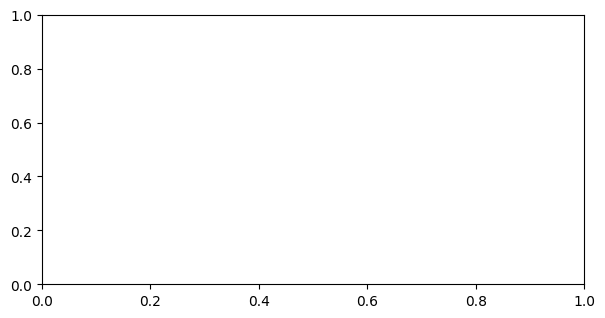

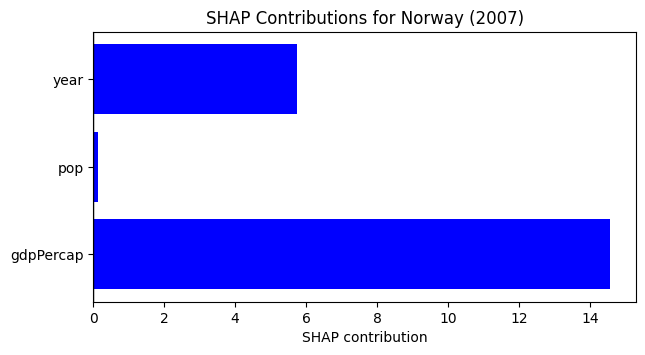

In [4]:
X_model = gapminder[["gdpPercap", "pop", "year"]].values
y_model = gapminder["lifeExp"].values

# TODO 1: fit the model

rf = RandomForestRegressor(n_estimators=100, random_state=0)
rf.fit(X_model, y_model)

# TODO 2: SHAP explainer + values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

# TODO 3: find Norway's row, plot its SHAP contributions
row_idx = gapminder.index[(gapminder["country"] == "Norway") &
                          (gapminder["year"] == 2007)][0]
vals = shap_values[row_idx]

fig, ax = plt.subplots(figsize=(7, 3.5))

features = ["gdpPercap", "pop", "year"]
colors = ["blue" if v > 0 else "red" for v in vals]


fig, ax = plt.subplots(figsize=(7, 3.5))
# plot vals as a diverging horizontal bar chart here
ax.barh(features, vals, color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("SHAP contribution")
ax.set_title("SHAP Contributions for Norway (2007)")

plt.show()




**Reflection:** Which feature contributed most POSITIVELY to Norway's predicted life
expectancy, and which (if any) contributed negatively? Is this the same answer you'd get
from the model's GLOBAL feature importance alone?

_Your answer:_The feature with the largest positive contribution is gdpPercap because Norway's high GDP per capita pushes its predicted life expectancy up. The negative contribution comes from pop since Norway has a small population. Global feature importance would not give the same answer because it only ranks features on average across all predictions, not for one specific country.

## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

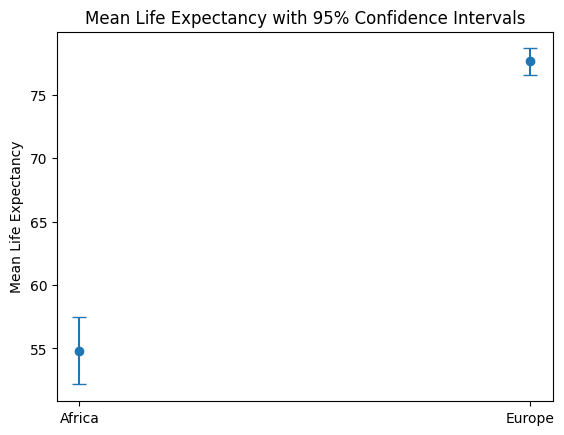

In [5]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    # TODO 1: resample `values` with replacement n_boot times, take the mean each time,
    # then return (overall mean, 2.5th percentile of boot means, 97.5th percentile)
    boot_means = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_means.append(np.mean(sample))

    mean = np.mean(values)
    ci_low = np.percentile(boot_means, 2.5)
    ci_high = np.percentile(boot_means, 97.5)

    return mean, ci_low, ci_high
    pass

# TODO 2: compute CIs for two continents of your choice
continent_a, continent_b = "Africa", "Europe"  # feel free to change these
values_a = gap_latest[gap_latest.continent == continent_a].lifeExp.values
values_b = gap_latest[gap_latest.continent == continent_b].lifeExp.values

result_a = bootstrap_ci(values_a)
result_b = bootstrap_ci(values_b)

# TODO 3: plot both as error bars (mean +/- CI half-width) on one chart
means = [result_a[0], result_b[0]]
errors = [
    [result_a[0] - result_a[1], result_b[0] - result_b[1]],
    [result_a[2] - result_a[0], result_b[2] - result_b[0]]
]

plt.errorbar(
    [continent_a, continent_b],
    means,
    yerr=errors,
    fmt="o",
    capsize=5
)

plt.ylabel("Mean Life Expectancy")
plt.title("Mean Life Expectancy with 95% Confidence Intervals")
plt.show()



**Reflection:** Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
size (n), or both?

_Your answer:_Africa has the wider confidence interval. This is mainly because African countries vary much more in life expectancy (higher SD), while European countries cluster tightly. Sample size also affects width, but here the SD difference is the dominant factor.

## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

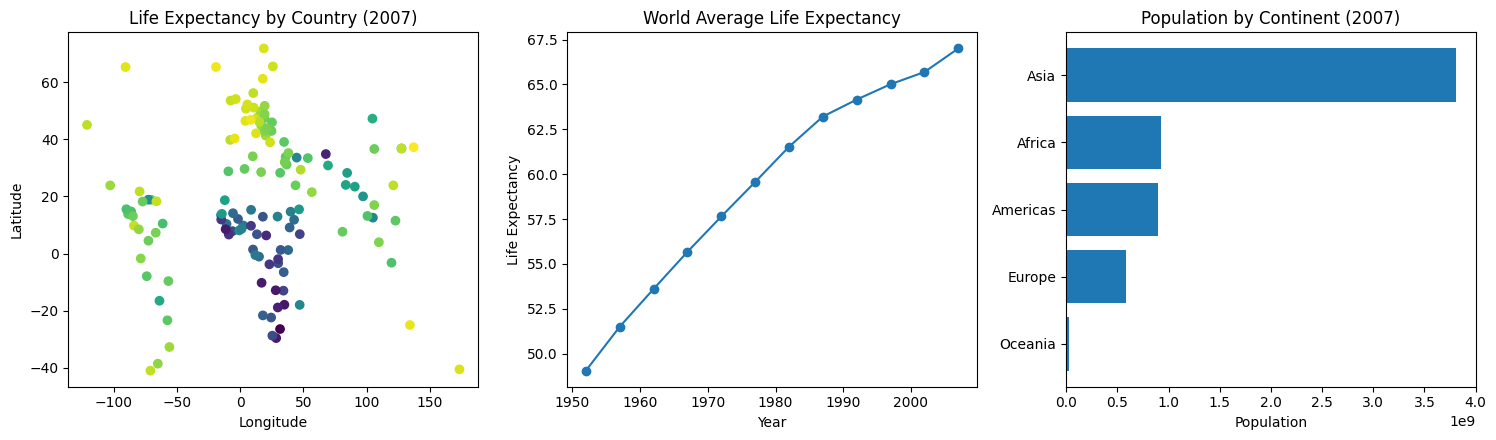

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# TODO 1: map-style scatter (axes[0])
axes[0].scatter(
    gap_latest["centroid_lon"],
    gap_latest["centroid_lat"],
    c=gap_latest["lifeExp"],
    cmap="viridis"
)
axes[0].set_title("Life Expectancy by Country (2007)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")



# TODO 2: world trend line (axes[1])
world_avg = gapminder.groupby("year")["lifeExp"].mean()

axes[1].plot(world_avg.index, world_avg.values, marker="o")
axes[1].set_title("World Average Life Expectancy")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Life Expectancy")


# TODO 3: population by continent bar chart (axes[2])
pop_continent = (
    gap_latest.groupby("continent")["pop"]
    .sum()
    .sort_values()
)

axes[2].barh(pop_continent.index, pop_continent.values)
axes[2].set_title("Population by Continent (2007)")
axes[2].set_xlabel("Population")



plt.tight_layout()
plt.show()

**Reflection:** If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

_Your answer:_I would keep the trend line because it answers the monitoring question “Is world life expectancy increasing, decreasing, or showing an emerging change over time?”

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence recommendation to your director covering
the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports,
  and why.
- State whether you'd lead with global or local feature importance when a journalist
  asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate
  without uncertainty, and why.

_Your final recommendation here:_I would standardize on rate based maps because they allow fair comparisons between countries of different population sizes, unlike count maps which are dominated by population. When a journalist asks about a specific country, I would use local feature importance because it explains that individual prediction, while global importance only shows average model behavior. I would never show the mean life expectancy per continent without its confidence interval, since every value is an estimate and a bare number would look like a certain fact.



In [12]:
print(centroids.columns)


Index(['iso_alpha', 'centroid_lon', 'centroid_lat'], dtype='object')
